# CSP + LDA Familiarity Modellability

This notebook builds a Common Spatial Patterns (CSP) plus Linear Discriminant Analysis (LDA) pipeline to test whether trial-level EEG can predict binary familiarity judgments (`responded`: familiar vs. not familiar). The primary target is modellability rather than coefficient interpretation, so the notebook emphasizes cross-validated performance under participant-aware evaluation.

Unlike the analysis-ready feature notebook, this one intentionally gives the classifier direct access to the multichannel EEG epochs instead of hand-crafted behavioral covariates. That makes it a cleaner test of whether the neural signal itself carries enough information to distinguish familiar from unfamiliar song responses.


## Plain-Language Interpretation

This analysis asks a simple question: if we look at each participant's EEG signal while they hear a song, is there enough information in that brain activity to predict whether they will report the song as familiar?

To test that, the notebook starts with the raw EEG recordings in `ds005876/` and cuts them into short stimulus-locked trials, so each song presentation becomes one EEG example. For each trial, the model does not use song titles, demographics, or hand-built behavioral features as predictors. Instead, it uses the participant's multichannel EEG time series itself, summarized through a **Common Spatial Patterns (CSP)** transform. CSP learns spatial filters that emphasize differences in the EEG patterns associated with the two labels: `familiar` versus `not familiar`.

Those CSP features are then passed into **Linear Discriminant Analysis (LDA)**, which tries to separate the two familiarity classes. The notebook tunes how many CSP components to keep, compares the EEG model against a dummy baseline, and then evaluates performance in participant-aware ways. The most important evaluation is leave-one-subject-out testing: the model is trained on EEG data from other participants and then asked to predict familiarity for a completely unseen participant. That is the key check for whether the EEG signal reflects a generalizable familiarity pattern rather than just subject-specific noise.

If the grouped and LOSO scores stay close to chance, the correct conclusion is not that the notebook failed technically. It means the chosen EEG representation and classifier are only weakly informative for this target in this dataset.


# Pipeline Overview

1. Load the trial labels from the analysis-ready table and align them to stimulus-locked EEG epochs from `ds005876/`.
2. Inspect the pre-modeling EEG signal with participant balance summaries, stimulus-locked waveforms, and scalp topographies before fitting any classifier.
3. Tune the number of CSP components under grouped cross-validation, always holding out entire participants within each fold.
4. Stress test the chosen pipeline with leave-one-subject-out evaluation and within-subject reference models.
5. Close with compact visual diagnostics that summarize the generalization story.

The notebook is organized in the same order a cautious EEG modeling workflow should follow: build aligned data, verify the signal looks sensible, tune only under grouped validation, then report the hardest generalization test separately from easier within-subject results.


## Detailed Modeling Map

This notebook answers a narrower question than the analysis-ready table notebook: not "what features exist?" but "does the EEG alone contain enough structure to support a usable familiarity classifier?"

The full modeling process is:

1. Load trial labels from `analysis_ready_familiarity_trials.csv`, but keep only the columns needed to align each EEG epoch with a binary familiarity outcome and a few audit fields such as participant ID, song file, and note rate.
2. Build a stimulus-locked EEG tensor by reading each participant's EEGLAB recording, filtering it to a broad 1-30 Hz band, resampling to 128 Hz, and extracting 2-second epochs starting exactly at each song onset.
3. Cache that `(trial, channel, time)` tensor to disk so future notebook reruns can start from a stable intermediate representation instead of repeatedly reloading and re-epoching every raw EEG file.
4. Reconstruct an `epoch_index` table that maps each row of the cached tensor back to `participant_id`, `trial_index`, and the original familiarity label. That mapping is what keeps later model results interpretable.
5. Inspect the data before modeling: participant label balance, global field power traces, representative channel averages, and scalp topographies. These plots are sanity checks that the stimulus-locked EEG contains nontrivial structure and that the class labels are not degenerate.
6. Tune the number of CSP components with `StratifiedGroupKFold`, which preserves class balance as much as possible while keeping each participant entirely inside a single fold. This is essential because EEG signatures are highly person-specific.
7. Compare the best CSP + LDA pipeline against a dummy baseline that knows only the overall familiar/not-familiar class rate. That comparison prevents small metric lifts from being overinterpreted.
8. Run leave-one-subject-out (LOSO) testing with the tuned component count. Each fold trains on all other participants and predicts one unseen participant, which is the strictest cross-subject generalization test in the notebook.
9. Run a secondary within-subject reference analysis. This does not answer the same question as LOSO, but it reveals whether some participants are separable only with subject-specific EEG structure.
10. Export all tuning tables, subject-level results, predictions, and summary figures so later reporting notebooks or paper figures can reuse them without rerunning the full model pipeline.

The main interpretation rule is simple: grouped or LOSO performance matters more than within-subject performance. If a model only looks good when train and test data come from the same person, it is not strong evidence of a general familiarity decoder.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from mne.decoding import CSP
from mne.viz import plot_topomap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")
sns.set_theme(style="whitegrid", context="notebook")

# EEG preprocessing and epoching parameters. These choices define the exact signal
# representation the model sees, so they are part of the modeling specification.
L_FREQ = 1.0
H_FREQ = 30.0
EPOCH_TMIN = 0.0
EPOCH_TMAX = 2.0
RESAMPLE_HZ = 128

# Candidate CSP dimensionalities to compare under grouped CV. The sweep tests how
# much spatial complexity the data can support before variance dominates.
COMPONENT_GRID = [2, 4, 6, 8, 10, 12]


def locate_project_root() -> Path:
    # The notebook may be executed from the project root or from notebooks/, so
    # probe both locations before failing.
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "ds005876").exists() and (candidate / "analysis").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing ds005876 and analysis directories.")


ROOT = locate_project_root()
DATA_DIR = ROOT / "ds005876"
ANALYSIS_DIR = ROOT / "analysis"
PLOT_DIR = ROOT / "visuals" / "analysis_ready"

# Persist every expensive or report-worthy artifact so the notebook is useful both
# as an analysis document and as a reproducible data-product generator.
CACHE_PATH = ANALYSIS_DIR / "csp_lda_epoch_cache.npz"
TUNING_PATH = ANALYSIS_DIR / "csp_lda_component_tuning.csv"
GROUPED_PATH = ANALYSIS_DIR / "csp_lda_grouped_results.csv"
LOSO_PATH = ANALYSIS_DIR / "csp_lda_loso_subject_results.csv"
WITHIN_PATH = ANALYSIS_DIR / "csp_lda_within_subject_results.csv"
PREDICTIONS_PATH = ANALYSIS_DIR / "csp_lda_loso_predictions.csv"
SUMMARY_PLOT_PATH = PLOT_DIR / "csp_lda_familiarity_summary.png"
PREMODELING_OVERVIEW_PATH = PLOT_DIR / "csp_lda_premodeling_overview.png"
PREMODELING_TOPO_PATH = PLOT_DIR / "csp_lda_premodeling_topographies.png"
TUNING_PLOT_PATH = PLOT_DIR / "csp_lda_tuning_diagnostics.png"
LOSO_PLOT_PATH = PLOT_DIR / "csp_lda_loso_diagnostics.png"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Epoch cache: {CACHE_PATH}")


Project root: C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26
Epoch cache: C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\analysis\csp_lda_epoch_cache.npz


## 1. Build Stimulus-Locked EEG Epochs

This stage turns raw EEGLAB recordings into the actual model input matrix. The output is not yet a 2D feature table; it is a 3D tensor `X` with shape `(trial, channel, time)` plus aligned label and index arrays.

That construction matters because the later CSP step expects multichannel time-series data, not precomputed scalar features. The preprocessing here is deliberately modest:

- bandpass filter to 1-30 Hz to focus on broad EEG rhythms and remove very slow drift / high-frequency noise,
- resample to 128 Hz to reduce memory and runtime,
- epoch from 0 to 2 seconds after song onset so every trial has the same duration,
- keep participant IDs and trial indices so results can be traced back to the original study tables.

The code below also caches the epoch tensor to `analysis/csp_lda_epoch_cache.npz`. That cache is important because raw `.set` loading and epoch extraction are the slowest part of the notebook, while the actual model fitting is relatively cheap.


In [2]:
def load_trial_metadata() -> pd.DataFrame:
    # Pull the labels from the already-built analysis table rather than rebuilding
    # them from scratch here. This keeps the target definition consistent across
    # notebooks and minimizes the number of fields carried into the model stage.
    trial_df = pd.read_csv(ANALYSIS_DIR / "analysis_ready_familiarity_trials.csv")
    keep_cols = [
        "participant_id",
        "trial_index",
        "responded",
        "responded_label",
        "songFileName",
        "songDur",
        "note_rate",
    ]
    # Keep only the fields needed to align cached EEG epochs with the trial labels.
    return trial_df[keep_cols].drop_duplicates(["participant_id", "trial_index", "responded"])


def build_epoch_cache(use_cache: bool = True) -> dict:
    # Reuse the saved tensor when available because raw EEGLAB loading is expensive.
    if use_cache and CACHE_PATH.exists():
        cache = np.load(CACHE_PATH, allow_pickle=True)
        return {
            "X": cache["X"],
            "y": cache["y"],
            "groups": cache["groups"].astype(str),
            "trial_index": cache["trial_index"].astype(int),
            "channel_names": cache["channel_names"].astype(str),
        }

    X_parts = []
    y_parts = []
    group_parts = []
    trial_parts = []
    channel_names = None

    # Build the epoch tensor subject by subject so missing files only remove the
    # affected participant instead of breaking the entire modeling dataset.
    for participant_id in sorted(path.name for path in DATA_DIR.glob("sub-*") if path.is_dir()):
        beh_path = DATA_DIR / participant_id / "beh" / f"{participant_id}_task-songfamiliarity_beh.tsv"
        eeg_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_eeg.set"
        events_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_events.tsv"
        if not (beh_path.exists() and eeg_path.exists() and events_path.exists()):
            continue

        behavior_df = pd.read_csv(beh_path, sep="\t")
        labels = pd.to_numeric(behavior_df["responded"], errors="coerce").fillna(0).astype(int).to_numpy()
        events_df = pd.read_csv(events_path, sep="\t")

        # Event value "1" with a real stimulus file marks the start of a song trial.
        trial_starts = events_df[
            (events_df["value"].astype(str) == "1")
            & (events_df["stim_file"].astype(str) != "n/a")
        ].reset_index(drop=True)
        if trial_starts.empty:
            continue

        raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=False)

        # Apply a broad EEG bandpass and a lower sampling rate so CSP operates on a
        # cleaner, more compact trial tensor. This is a pragmatic preprocessing step,
        # not a claim that these are the optimal signal-processing settings.
        raw.filter(L_FREQ, H_FREQ, picks="eeg", verbose=False)
        raw.resample(RESAMPLE_HZ, npad="auto", verbose=False)
        eeg_picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
        sfreq = raw.info["sfreq"]
        onsets = trial_starts["onset"].to_numpy(dtype=float)

        # Every onset becomes the anchor for one 2-second stimulus-locked epoch.
        event_array = np.column_stack([
            (onsets * sfreq).astype(int),
            np.zeros(len(onsets), dtype=int),
            np.ones(len(onsets), dtype=int),
        ])
        epochs = mne.Epochs(
            raw,
            event_array,
            event_id={"trial": 1},
            tmin=EPOCH_TMIN,
            tmax=EPOCH_TMAX,
            baseline=None,
            picks=eeg_picks,
            preload=True,
            on_missing="ignore",
            verbose=False,
        )
        X_sub = epochs.get_data(copy=True).astype(np.float32)

        # Behavior rows and extracted epochs should correspond trial-for-trial, but
        # this truncation guards against edge cases where one source has extra rows.
        n_trials = min(len(labels), len(X_sub))
        if n_trials == 0:
            continue

        X_parts.append(X_sub[:n_trials])
        y_parts.append(labels[:n_trials])
        group_parts.extend([participant_id] * n_trials)
        trial_parts.extend(range(n_trials))
        if channel_names is None:
            channel_names = np.array([raw.ch_names[idx] for idx in eeg_picks], dtype=object)
        print(f"Extracted {participant_id}: {n_trials} trials")

    # Concatenate the participant-specific arrays into one modeling bundle. At this
    # point, every row in X still has a matching label, participant group, and trial index.
    X = np.concatenate(X_parts, axis=0)
    y = np.concatenate(y_parts, axis=0)
    groups = np.array(group_parts, dtype=object)
    trial_index = np.array(trial_parts, dtype=int)

    # Save the full epoch tensor once so future reruns can start from the cached features.
    np.savez_compressed(
        CACHE_PATH,
        X=X,
        y=y,
        groups=groups,
        trial_index=trial_index,
        channel_names=channel_names,
    )
    return {
        "X": X,
        "y": y,
        "groups": groups.astype(str),
        "trial_index": trial_index,
        "channel_names": channel_names.astype(str),
    }


def make_csp_lda(n_components: int) -> Pipeline:
    # CSP learns spatial filters from the multichannel EEG, and LDA performs the
    # final binary familiarity classification on those transformed features.
    # `reg='ledoit_wolf'` and shrinkage in LDA are regularization choices that help
    # stabilize the covariance estimates when trial counts are limited.
    return Pipeline(
        [
            ("csp", CSP(n_components=n_components, reg="ledoit_wolf", log=True, norm_trace=False)),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]
    )


def summarize_cv(scores: dict, prefix: str = "") -> dict:
    # Cross-validation returns one score per fold; collapse those into mean and SD
    # so tuning tables and plots can compare model settings compactly.
    out = {}
    for metric_name in ["roc_auc", "accuracy", "balanced_accuracy", "f1"]:
        values = scores[f"test_{metric_name}"]
        out[f"{prefix}{metric_name}_mean"] = np.nanmean(values)
        out[f"{prefix}{metric_name}_std"] = np.nanstd(values)
    return out


def load_template_info(channel_names: np.ndarray) -> mne.Info:
    # Topography plots need channel locations. Reuse the montage from the first EEG
    # file that contains the full requested channel set.
    for participant_id in sorted(path.name for path in DATA_DIR.glob("sub-*") if path.is_dir()):
        eeg_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_eeg.set"
        if not eeg_path.exists():
            continue

        raw = mne.io.read_raw_eeglab(eeg_path, preload=False, verbose=False)
        if not set(channel_names).issubset(raw.ch_names):
            continue

        info = mne.create_info(list(channel_names), sfreq=RESAMPLE_HZ, ch_types="eeg")
        montage = raw.get_montage()
        if montage is not None:
            info.set_montage(montage, on_missing="ignore")
        return info

    raise FileNotFoundError("Could not load channel locations for the EEG topography plots.")


def nearest_time_indices(times: np.ndarray, requested_times: list[float]) -> list[int]:
    # Requested plotting times may not fall exactly on the resampled grid, so map
    # them to the nearest available time indices.
    return [int(np.argmin(np.abs(times - time_value))) for time_value in requested_times]


bundle = build_epoch_cache(use_cache=True)
trial_meta = load_trial_metadata()
X = bundle["X"]
y = bundle["y"]
groups = bundle["groups"]
trial_index = bundle["trial_index"]
channel_names = bundle["channel_names"]
times = np.linspace(EPOCH_TMIN, EPOCH_TMAX, X.shape[2])
info_template = load_template_info(channel_names)

# This index table makes the cached EEG tensor interpretable again after extraction.
# It is the bridge between raw arrays used by scikit-learn and human-readable trial metadata.
epoch_index = pd.DataFrame(
    {
        "participant_id": groups,
        "trial_index": trial_index,
        "responded": y,
    }
)
epoch_index = epoch_index.merge(trial_meta, on=["participant_id", "trial_index", "responded"], how="left")
display(
    pd.DataFrame(
        {
            "rows": [len(epoch_index)],
            "participants": [epoch_index["participant_id"].nunique()],
            "channels": [X.shape[1]],
            "timepoints_per_epoch": [X.shape[2]],
            "familiar_rate": [y.mean()],
        }
    )
)
display(epoch_index.head())


,rows,participants,channels,timepoints_per_epoch,familiar_rate
0,2074,29,32,257,0.496625


,participant_id,trial_index,responded,responded_label,songFileName,songDur,note_rate
0,sub-01,0,0,Not familiar,do wah ditty.wav,7.758005,1.345483
1,sub-01,1,1,Familiar,alouette.wav,5.946984,0.986547
2,sub-01,2,1,Familiar,great escape.wav,15.750023,1.689532
3,sub-01,3,1,Familiar,buffalo gals.wav,9.331020,0.971860
4,sub-01,4,0,Not familiar,over the river and through the woods.wav,13.913016,2.294688


## 2. Pre-Modeling EEG Overview

Before fitting CSP + LDA, it helps to verify that the class balance is usable, the stimulus-locked EEG contains structured temporal variation, and the scalp distributions are not identical across familiarity conditions. The figures below summarize participant-level balance, class-conditional waveform structure, and MNE topographies of the average familiar versus unfamiliar response.

This section is not optional boilerplate. In EEG modeling, a classifier can look unstable or meaningless simply because one class is too rare for some participants, because epochs are badly aligned, or because the signal representation has no visible condition structure at all. These plots are a fast diagnostic that the notebook is at least modeling a coherent stimulus-locked dataset.


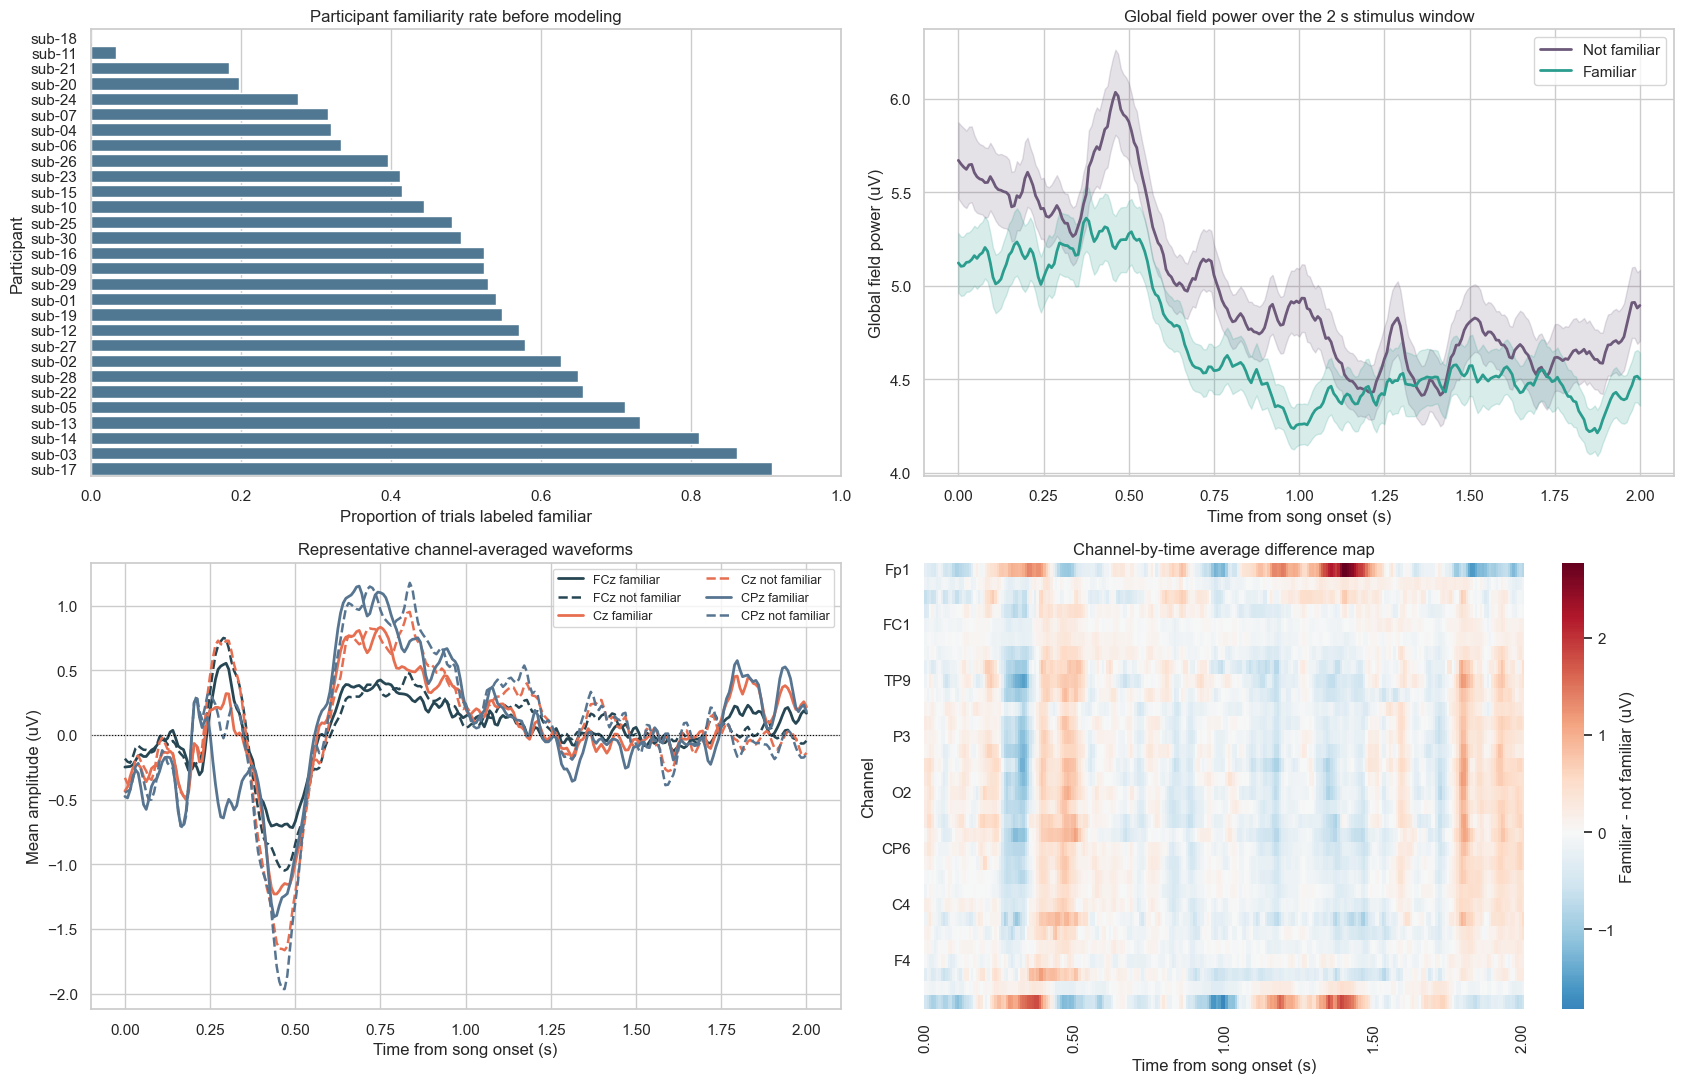

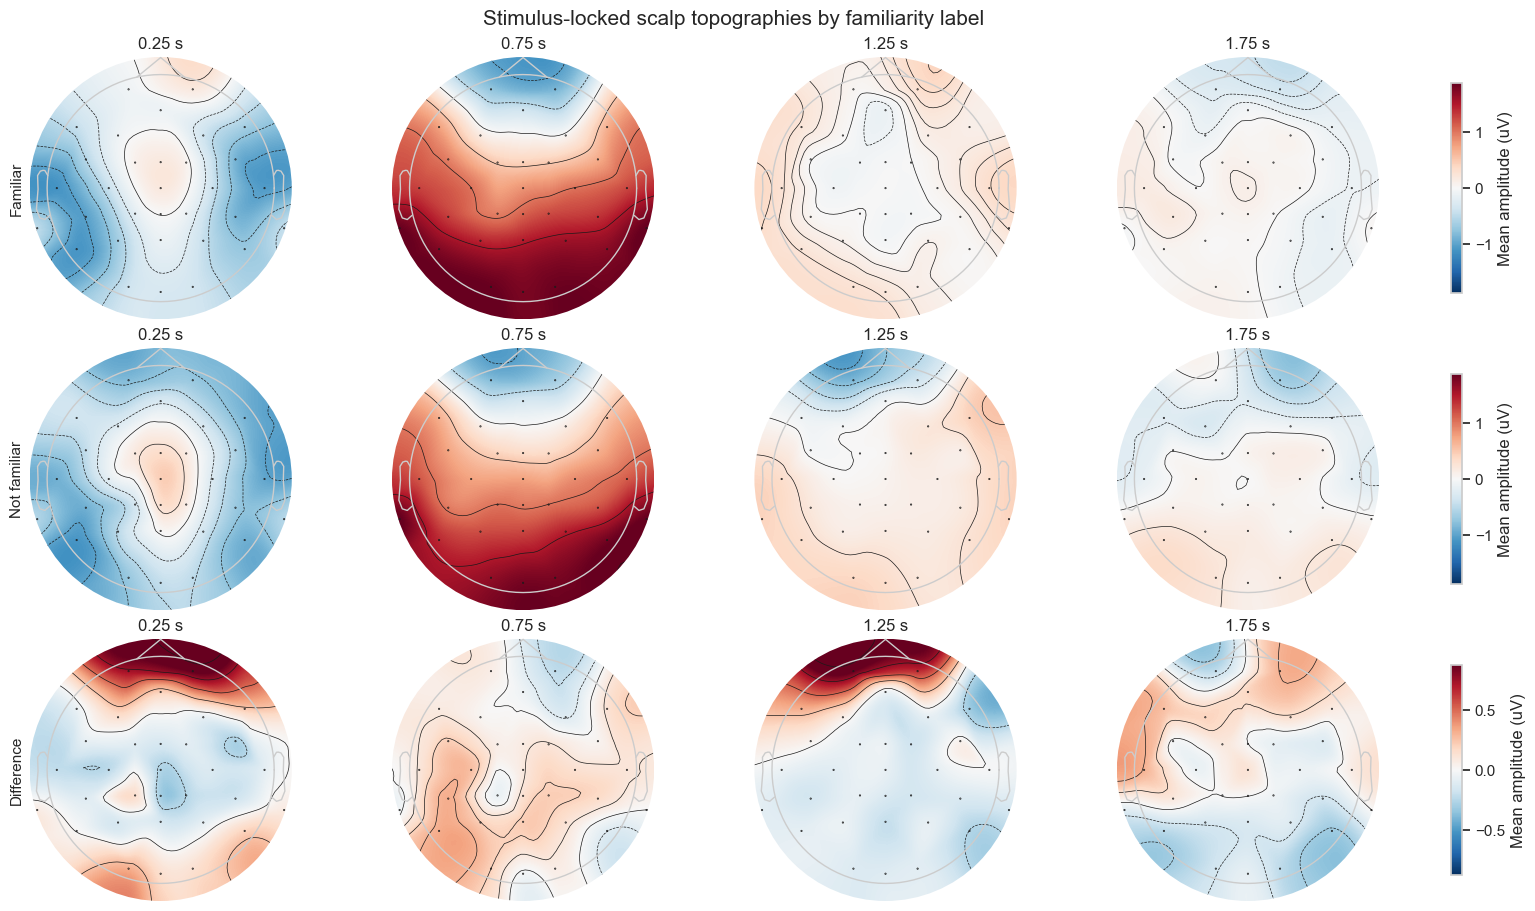

Saved pre-modeling EEG overview to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\visuals\analysis_ready\csp_lda_premodeling_overview.png
Saved pre-modeling topographies to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\visuals\analysis_ready\csp_lda_premodeling_topographies.png


In [3]:
participant_summary = (
    epoch_index.groupby("participant_id")
    .agg(n_trials=("responded", "size"), familiar_rate=("responded", "mean"))
    .sort_values(["familiar_rate", "n_trials"])
    .reset_index()
)

label_styles = {
    0: {"name": "Not familiar", "color": "#6d597a"},
    1: {"name": "Familiar", "color": "#2a9d8f"},
}

# Average the epoched EEG separately by class so the notebook can inspect whether
# familiar and unfamiliar trials differ in broad waveform shape or scalp pattern.
familiar_avg_uv = X[y == 1].mean(axis=0) * 1e6
not_familiar_avg_uv = X[y == 0].mean(axis=0) * 1e6
diff_avg_uv = familiar_avg_uv - not_familiar_avg_uv

# Global field power collapses each epoch to scalp-wide variability over time.
gfp = X.std(axis=1) * 1e6
gfp_summary = {}
for label_value, style in label_styles.items():
    label_mask = y == label_value
    label_gfp = gfp[label_mask]
    gfp_summary[label_value] = {
        "mean": label_gfp.mean(axis=0),
        "sem": label_gfp.std(axis=0, ddof=1) / np.sqrt(label_gfp.shape[0]),
        "style": style,
    }

# Plot a few representative channels to make the condition-wise waveform comparison
# easier to read than the full channel-by-time matrix.
focus_channels = [name for name in ["FCz", "Cz", "CPz", "Pz", "F3", "F4"] if name in channel_names][:3]
if len(focus_channels) < 3:
    focus_channels = list(channel_names[:3])

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

# Participant label balance matters because highly skewed participants can make
# both training and held-out evaluation unstable.
sns.barplot(
    data=participant_summary,
    x="familiar_rate",
    y="participant_id",
    color="#457b9d",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Participant familiarity rate before modeling")
axes[0, 0].set_xlabel("Proportion of trials labeled familiar")
axes[0, 0].set_ylabel("Participant")
axes[0, 0].set_xlim(0, 1)

# Compare average global field power over time for the two labels.
for label_value, summary in gfp_summary.items():
    style = summary["style"]
    axes[0, 1].plot(times, summary["mean"], color=style["color"], linewidth=2, label=style["name"])
    axes[0, 1].fill_between(
        times,
        summary["mean"] - summary["sem"],
        summary["mean"] + summary["sem"],
        color=style["color"],
        alpha=0.18,
    )
axes[0, 1].set_title("Global field power over the 2 s stimulus window")
axes[0, 1].set_xlabel("Time from song onset (s)")
axes[0, 1].set_ylabel("Global field power (uV)")
axes[0, 1].legend(frameon=True)

channel_palette = ["#264653", "#e76f51", "#577590"]
for color, channel_name in zip(channel_palette, focus_channels):
    channel_idx = int(np.where(channel_names == channel_name)[0][0])
    axes[1, 0].plot(times, familiar_avg_uv[channel_idx], color=color, linewidth=2, label=f"{channel_name} familiar")
    axes[1, 0].plot(
        times,
        not_familiar_avg_uv[channel_idx],
        color=color,
        linestyle="--",
        linewidth=1.8,
        label=f"{channel_name} not familiar",
    )
axes[1, 0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[1, 0].set_title("Representative channel-averaged waveforms")
axes[1, 0].set_xlabel("Time from song onset (s)")
axes[1, 0].set_ylabel("Mean amplitude (uV)")
axes[1, 0].legend(ncol=2, fontsize=9)

# The heatmap exposes where in channel-time space the class-conditional means differ.
heatmap = sns.heatmap(
    diff_avg_uv,
    cmap="RdBu_r",
    center=0,
    ax=axes[1, 1],
    cbar_kws={"label": "Familiar - not familiar (uV)"},
)
axes[1, 1].set_title("Channel-by-time average difference map")
axes[1, 1].set_xlabel("Time from song onset (s)")
axes[1, 1].set_ylabel("Channel")
xticks = np.linspace(0, len(times) - 1, 5, dtype=int)
axes[1, 1].set_xticks(xticks + 0.5)
axes[1, 1].set_xticklabels([f"{times[idx]:.2f}" for idx in xticks])
yticks = np.arange(0, len(channel_names), 4)
axes[1, 1].set_yticks(yticks + 0.5)
axes[1, 1].set_yticklabels(channel_names[yticks], rotation=0)

fig.tight_layout()
fig.savefig(PREMODELING_OVERVIEW_PATH, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

# Topographies convert the class averages into scalp maps at a few representative
# times so the reader can see whether class differences are spatially structured.
requested_times = [0.25, 0.75, 1.25, 1.75]
time_indices = nearest_time_indices(times, requested_times)
topography_rows = [
    ("Familiar", familiar_avg_uv, np.max(np.abs(familiar_avg_uv[:, time_indices]))),
    ("Not familiar", not_familiar_avg_uv, np.max(np.abs(not_familiar_avg_uv[:, time_indices]))),
    ("Difference", diff_avg_uv, np.max(np.abs(diff_avg_uv[:, time_indices]))),
]

fig, axes = plt.subplots(len(topography_rows), len(time_indices), figsize=(16, 9), constrained_layout=True)
for row_index, (row_label, scalp_data, vmax) in enumerate(topography_rows):
    vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1.0
    color_limits = (-vmax, vmax)
    row_image = None
    for col_index, time_idx in enumerate(time_indices):
        row_image, _ = plot_topomap(
            scalp_data[:, time_idx],
            info_template,
            axes=axes[row_index, col_index],
            cmap="RdBu_r",
            vlim=color_limits,
            contours=6,
            show=False,
        )
        axes[row_index, col_index].set_title(f"{times[time_idx]:.2f} s")
        if col_index == 0:
            axes[row_index, col_index].set_ylabel(row_label, fontsize=11)
    fig.colorbar(row_image, ax=axes[row_index, :], shrink=0.8, label="Mean amplitude (uV)")

fig.suptitle("Stimulus-locked scalp topographies by familiarity label", fontsize=15)
fig.savefig(PREMODELING_TOPO_PATH, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved pre-modeling EEG overview to {PREMODELING_OVERVIEW_PATH}")
print(f"Saved pre-modeling topographies to {PREMODELING_TOPO_PATH}")


## 3. Tune CSP Dimensionality With Grouped Cross-Validation

The component sweep answers a narrow but important question: how many spatial filters can be estimated before variance outweighs signal? Using grouped folds ensures that the tuning decision reflects cross-subject transfer rather than memorizing one person's EEG signature.

This is the core model-selection stage. The notebook does not tune the classifier on leave-one-subject-out directly because that would be expensive and noisy for a first pass. Instead, it uses grouped 5-fold CV to choose a reasonable CSP dimensionality, then freezes that setting for the stricter LOSO evaluation.

The metrics reported here serve different purposes:

- `ROC AUC`: ranking quality and the main threshold-independent metric.
- `balanced_accuracy`: useful when some folds have imperfect class balance.
- `accuracy`: easy to interpret but more sensitive to class prevalence.
- `F1`: whether the predicted positive class is being recovered with any precision/recall balance.

The dummy baseline is not a formality. If CSP + LDA cannot beat a prior-only classifier under grouped validation, there is little evidence that the EEG representation is useful for this target.


,n_components,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std
0,2,0.546166,0.047257,0.505293,0.064726,0.515654,0.053044,0.480753,0.166267
1,4,0.543324,0.044206,0.509515,0.050548,0.515639,0.042383,0.486155,0.083005
2,10,0.529807,0.049704,0.503978,0.018346,0.516112,0.025722,0.444496,0.045789
3,12,0.520797,0.064540,0.498695,0.028647,0.508857,0.032365,0.444354,0.034538
4,6,0.492570,0.033293,0.462080,0.032888,0.475595,0.042054,0.426671,0.089978
5,8,0.487104,0.051990,0.480244,0.030892,0.491048,0.039471,0.444361,0.077619


,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std
0,dummy,0.500000,0.000000,0.463335,0.030304,0.500000,0.000000,0.248925,0.305349
1,csp_lda_2c,0.546166,0.047257,0.505293,0.064726,0.515654,0.053044,0.480753,0.166267


Best CSP component count under grouped 5-fold CV: 2


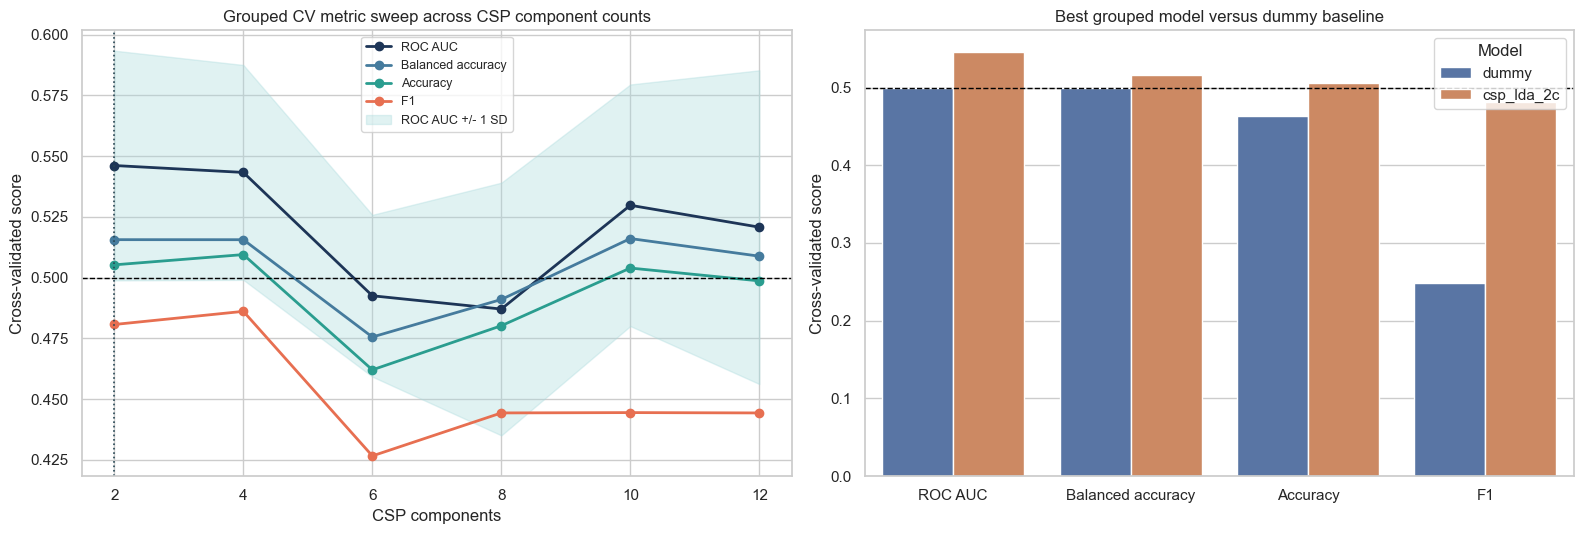

Saved tuning diagnostics to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\visuals\analysis_ready\csp_lda_tuning_diagnostics.png


In [4]:
# Grouped CV keeps each participant confined to a single fold, which is critical
# for testing cross-subject generalization rather than memorizing person-specific EEG.
grouped_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
}

tuning_rows = []
for n_components in COMPONENT_GRID:
    # Refit the full pipeline at each CSP dimensionality so the comparison reflects
    # the interaction between spatial compression and downstream LDA classification.
    scores = cross_validate(
        make_csp_lda(n_components),
        X,
        y,
        groups=groups,
        cv=grouped_cv,
        scoring=scoring,
        n_jobs=1,
    )
    tuning_rows.append({"n_components": n_components, **summarize_cv(scores)})

tuning_df = pd.DataFrame(tuning_rows).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
best_n_components = int(tuning_df.loc[0, "n_components"])

grouped_rows = []

# The dummy model provides the chance-level reference point for the grouped metrics.
dummy_scores = cross_validate(
    DummyClassifier(strategy="prior"),
    np.zeros((len(y), 1), dtype=float),
    y,
    groups=groups,
    cv=grouped_cv,
    scoring=scoring,
    n_jobs=1,
)
grouped_rows.append({"model": "dummy", **summarize_cv(dummy_scores)})

# Refit the best CSP dimensionality found above and compare it directly to the dummy baseline.
best_grouped_scores = cross_validate(
    make_csp_lda(best_n_components),
    X,
    y,
    groups=groups,
    cv=grouped_cv,
    scoring=scoring,
    n_jobs=1,
)
grouped_rows.append({"model": f"csp_lda_{best_n_components}c", **summarize_cv(best_grouped_scores)})

# Persist the grouped tuning outputs because these tables are the main evidence used
# to justify the chosen CSP dimensionality later in the notebook.
tuning_df.to_csv(TUNING_PATH, index=False)
grouped_df = pd.DataFrame(grouped_rows)
grouped_df.to_csv(GROUPED_PATH, index=False)

display(tuning_df)
display(grouped_df)
print(f"Best CSP component count under grouped 5-fold CV: {best_n_components}")

tuning_plot_df = tuning_df.sort_values("n_components").reset_index(drop=True)
metric_specs = [
    ("roc_auc_mean", "ROC AUC", "#1d3557"),
    ("balanced_accuracy_mean", "Balanced accuracy", "#457b9d"),
    ("accuracy_mean", "Accuracy", "#2a9d8f"),
    ("f1_mean", "F1", "#e76f51"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for metric_name, metric_label, metric_color in metric_specs:
    axes[0].plot(
        tuning_plot_df["n_components"],
        tuning_plot_df[metric_name],
        marker="o",
        linewidth=2,
        color=metric_color,
        label=metric_label,
    )
axes[0].fill_between(
    tuning_plot_df["n_components"],
    tuning_plot_df["roc_auc_mean"] - tuning_plot_df["roc_auc_std"],
    tuning_plot_df["roc_auc_mean"] + tuning_plot_df["roc_auc_std"],
    color="#a8dadc",
    alpha=0.35,
    label="ROC AUC +/- 1 SD",
)
axes[0].axhline(0.5, linestyle="--", linewidth=1, color="black")
axes[0].axvline(best_n_components, linestyle=":", linewidth=1.2, color="#264653")
axes[0].set_title("Grouped CV metric sweep across CSP component counts")
axes[0].set_xlabel("CSP components")
axes[0].set_ylabel("Cross-validated score")
axes[0].legend(frameon=True, fontsize=9)

# The right-hand panel translates the tuning decision into a simpler question:
# does the selected EEG model actually outperform a trivial class-prior baseline?
grouped_plot_df = grouped_df[
    ["model", "roc_auc_mean", "balanced_accuracy_mean", "accuracy_mean", "f1_mean"]
].melt(id_vars="model", var_name="metric", value_name="score")
grouped_plot_df["metric"] = grouped_plot_df["metric"].map(
    {
        "roc_auc_mean": "ROC AUC",
        "balanced_accuracy_mean": "Balanced accuracy",
        "accuracy_mean": "Accuracy",
        "f1_mean": "F1",
    }
)
sns.barplot(
    data=grouped_plot_df,
    x="metric",
    y="score",
    hue="model",
    ax=axes[1],
)
axes[1].axhline(0.5, linestyle="--", linewidth=1, color="black")
axes[1].set_title("Best grouped model versus dummy baseline")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cross-validated score")
axes[1].legend(title="Model", frameon=True)

fig.tight_layout()
fig.savefig(TUNING_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved tuning diagnostics to {TUNING_PLOT_PATH}")


## 4. Leave-One-Subject-Out Stress Test

Once the best component count is chosen, the notebook reruns the pipeline with one participant held out at a time. This is the most decision-relevant result because it matches the true deployment setting: can a model trained on other people generalize to someone new?

The LOSO section also computes a secondary within-subject reference analysis. That comparison should not be treated as equivalent evidence. Within-subject cross-validation is easier because the model can exploit person-specific signal structure that will not transfer to new participants. Its main value here is diagnostic: if within-subject scores are notably better than LOSO scores, the EEG may contain subject-specific separability without a shared cross-subject pattern.


,metric,value
0,oof_roc_auc,0.503803
1,mean_subject_accuracy,0.507826
2,mean_subject_balanced_accuracy,0.520275
3,mean_subject_f1,0.387947
4,subjects_with_defined_roc_auc,28.000000


,fold,participant_id,n_trials,familiar_rate,roc_auc,accuracy,balanced_accuracy,f1
0,1,sub-01,74,0.540541,0.480882,0.459459,0.429412,0.615385
1,2,sub-02,75,0.626667,0.538754,0.640000,0.517857,0.776860
2,3,sub-03,101,0.861386,0.435140,0.138614,0.500000,0.000000
3,4,sub-04,78,0.320513,0.558491,0.487179,0.538113,0.459459
4,5,sub-05,66,0.712121,0.591265,0.696970,0.552072,0.807692


,participant_id,n_trials,familiar_rate,valid_for_cv,roc_auc_mean,accuracy_mean,balanced_accuracy_mean
8,sub-10,63,0.444444,True,0.683810,0.541026,0.518095
14,sub-16,82,0.524390,True,0.621974,0.609559,0.603373
13,sub-15,77,0.415584,True,0.613757,0.609167,0.588095
21,sub-23,51,0.411765,True,0.595000,0.607273,0.548333
0,sub-01,74,0.540541,True,0.589881,0.556190,0.555357
20,sub-22,67,0.656716,True,0.580556,0.628571,0.527222
11,sub-13,71,0.732394,True,0.579394,0.732381,0.500000
26,sub-28,77,0.649351,True,0.572000,0.636667,0.516667
25,sub-27,69,0.579710,True,0.562500,0.549451,0.555833
28,sub-30,77,0.493506,True,0.548661,0.467500,0.473214


Average within-subject ROC AUC across evaluable participants: 0.514


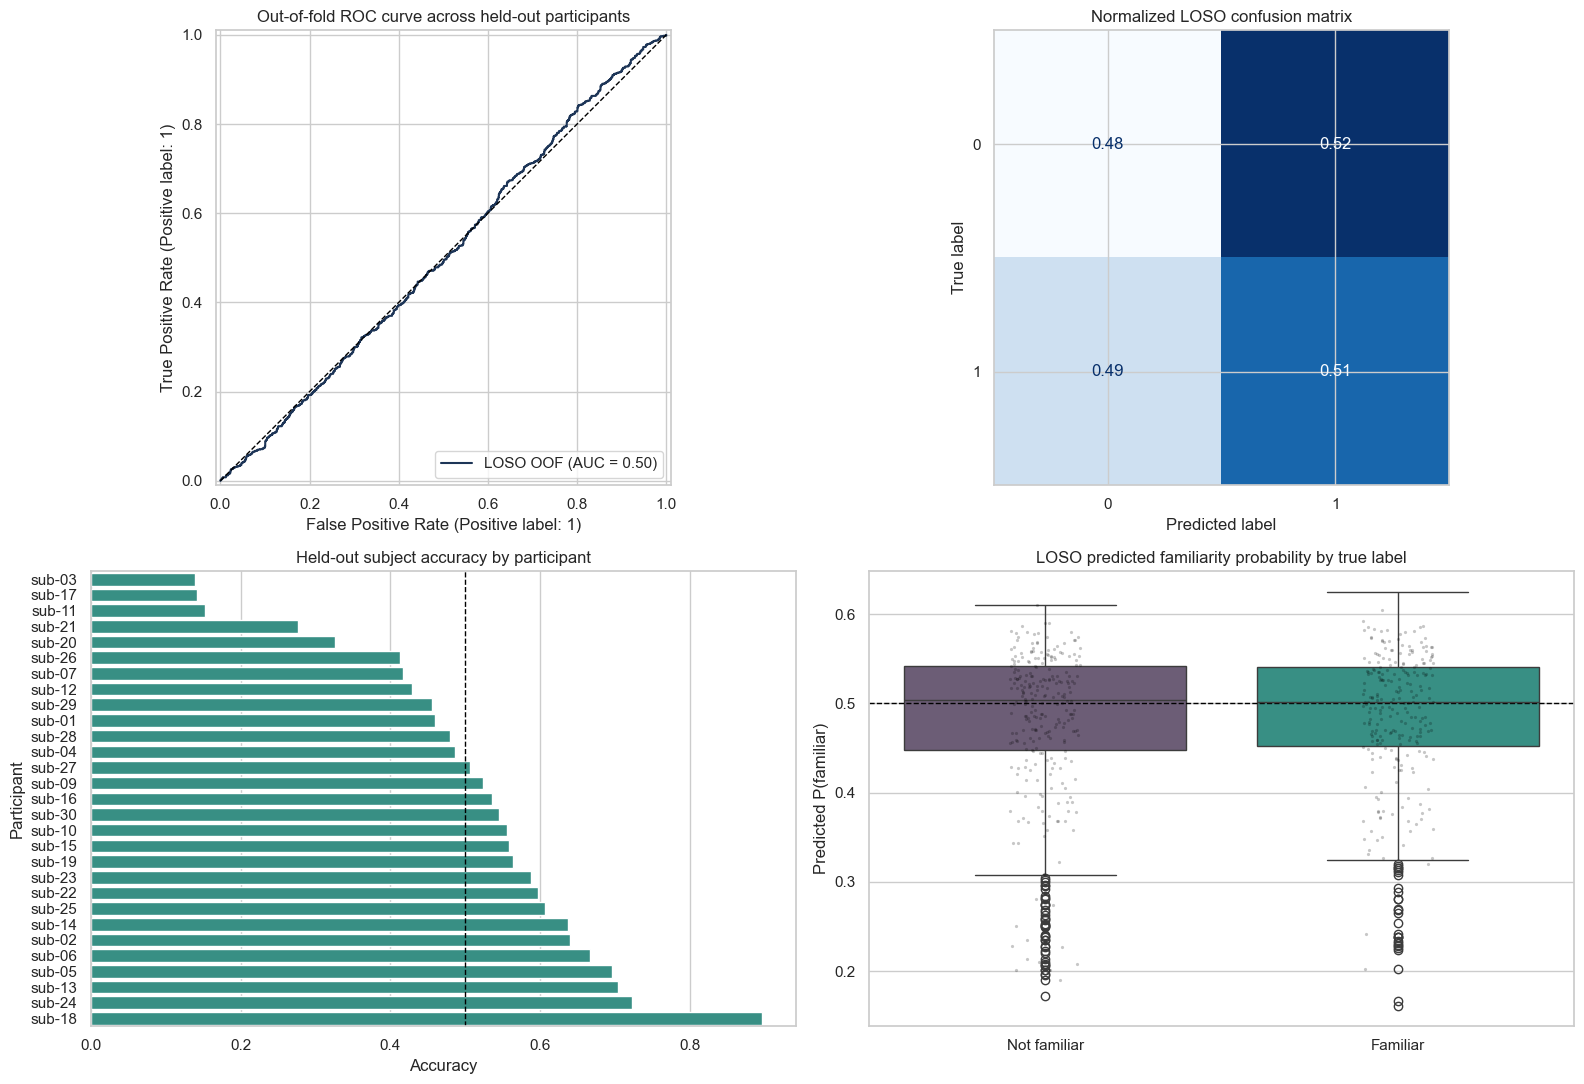

Saved LOSO diagnostics to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\visuals\analysis_ready\csp_lda_loso_diagnostics.png


In [5]:
logo = LeaveOneGroupOut()
oof_prob = np.full(len(y), np.nan, dtype=float)
loso_rows = []

# This is the strictest generalization test: train on other people, then predict one unseen participant.
for fold_index, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    participant_id = str(groups[test_idx][0])
    estimator = make_csp_lda(best_n_components)
    estimator.fit(X[train_idx], y[train_idx])
    prob = estimator.predict_proba(X[test_idx])[:, 1]
    pred = (prob >= 0.5).astype(int)
    y_test = y[test_idx]
    oof_prob[test_idx] = prob
    loso_rows.append(
        {
            "fold": fold_index,
            "participant_id": participant_id,
            "n_trials": len(test_idx),
            "familiar_rate": y_test.mean(),
            # ROC AUC is undefined when a held-out subject has only one class present.
            "roc_auc": np.nan if np.unique(y_test).size < 2 else roc_auc_score(y_test, prob),
            "accuracy": accuracy_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
        }
    )

loso_df = pd.DataFrame(loso_rows)
loso_df.to_csv(LOSO_PATH, index=False)

# Save out-of-fold predictions so later checks can inspect participant-level errors,
# threshold sensitivity, or song-specific failure cases without rerunning LOSO.
prediction_df = epoch_index.copy()
prediction_df["predicted_probability_familiar"] = oof_prob
prediction_df["predicted_label"] = (oof_prob >= 0.5).astype(int)
prediction_df["true_label_name"] = np.where(prediction_df["responded"] == 1, "Familiar", "Not familiar")
prediction_df.to_csv(PREDICTIONS_PATH, index=False)

# Summarize the LOSO run at the dataset level. The first metric uses all pooled OOF
# predictions, while the others average subject-level scores after holdout.
loso_summary = pd.DataFrame(
    {
        "metric": [
            "oof_roc_auc",
            "mean_subject_accuracy",
            "mean_subject_balanced_accuracy",
            "mean_subject_f1",
            "subjects_with_defined_roc_auc",
        ],
        "value": [
            roc_auc_score(y, oof_prob),
            loso_df["accuracy"].mean(),
            loso_df["balanced_accuracy"].mean(),
            loso_df["f1"].mean(),
            loso_df["roc_auc"].notna().sum(),
        ],
    }
)

within_rows = []
for participant_id in pd.unique(groups):
    participant_mask = groups == participant_id
    X_sub = X[participant_mask]
    y_sub = y[participant_mask]
    class_values, class_counts = np.unique(y_sub, return_counts=True)
    minority_count = int(class_counts.min()) if len(class_counts) else 0

    # Skip within-subject CV when one class is too rare to form stable splits.
    if len(class_values) < 2 or minority_count < 5:
        within_rows.append(
            {
                "participant_id": participant_id,
                "n_trials": len(y_sub),
                "familiar_rate": y_sub.mean(),
                "valid_for_cv": False,
                "roc_auc_mean": np.nan,
                "accuracy_mean": np.nan,
                "balanced_accuracy_mean": np.nan,
            }
        )
        continue

    # This is a reference analysis, not the primary claim: the model trains and tests
    # within the same participant, so higher scores here do not imply cross-subject utility.
    n_splits = min(5, minority_count)
    subject_scores = cross_validate(
        make_csp_lda(best_n_components),
        X_sub,
        y_sub,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
        scoring={
            "roc_auc": "roc_auc",
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
        },
        n_jobs=1,
    )
    within_rows.append(
        {
            "participant_id": participant_id,
            "n_trials": len(y_sub),
            "familiar_rate": y_sub.mean(),
            "valid_for_cv": True,
            "roc_auc_mean": subject_scores["test_roc_auc"].mean(),
            "accuracy_mean": subject_scores["test_accuracy"].mean(),
            "balanced_accuracy_mean": subject_scores["test_balanced_accuracy"].mean(),
        }
    )

within_df = pd.DataFrame(within_rows).sort_values("participant_id").reset_index(drop=True)
within_df.to_csv(WITHIN_PATH, index=False)
valid_within_df = within_df[within_df["valid_for_cv"]].copy()

display(loso_summary)
display(loso_df.head())
display(valid_within_df.sort_values("roc_auc_mean", ascending=False).head(10))
print(f"Average within-subject ROC AUC across evaluable participants: {valid_within_df['roc_auc_mean'].mean():.3f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Pool all LOSO predictions into one ROC curve so the notebook can summarize the
# overall ranking performance of the unseen-participant predictions.
RocCurveDisplay.from_predictions(y, oof_prob, ax=axes[0, 0], color="#1d3557", name="LOSO OOF")
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")
axes[0, 0].set_title("Out-of-fold ROC curve across held-out participants")

# The confusion matrix makes thresholded errors more interpretable than ROC AUC alone.
ConfusionMatrixDisplay.from_predictions(
    y,
    prediction_df["predicted_label"],
    normalize="true",
    ax=axes[0, 1],
    colorbar=False,
    cmap="Blues",
)
axes[0, 1].set_title("Normalized LOSO confusion matrix")

# Inspect who is easy versus hard to generalize to.
subject_accuracy_df = loso_df.sort_values("accuracy", ascending=True)
sns.barplot(
    data=subject_accuracy_df,
    x="accuracy",
    y="participant_id",
    color="#2a9d8f",
    ax=axes[1, 0],
)
axes[1, 0].axvline(0.5, linestyle="--", linewidth=1, color="black")
axes[1, 0].set_title("Held-out subject accuracy by participant")
axes[1, 0].set_xlabel("Accuracy")
axes[1, 0].set_ylabel("Participant")

# Show the distribution of predicted probabilities by true class to reveal whether
# the model meaningfully separates the classes or just clusters around 0.5.
sns.boxplot(
    data=prediction_df,
    x="true_label_name",
    y="predicted_probability_familiar",
    palette=["#6d597a", "#2a9d8f"],
    ax=axes[1, 1],
)
sns.stripplot(
    data=prediction_df.sample(min(len(prediction_df), 500), random_state=42),
    x="true_label_name",
    y="predicted_probability_familiar",
    color="black",
    alpha=0.22,
    size=2.3,
    ax=axes[1, 1],
)
axes[1, 1].axhline(0.5, linestyle="--", linewidth=1, color="black")
axes[1, 1].set_title("LOSO predicted familiarity probability by true label")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Predicted P(familiar)")

fig.tight_layout()
fig.savefig(LOSO_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved LOSO diagnostics to {LOSO_PLOT_PATH}")


## 5. Visual Diagnostics

The final figure still serves as the compact modeling summary: tuning behavior across component counts, grouped performance versus dummy, within-subject separability, and the relationship between class balance and participant-level modellability.

These plots compress the notebook's logic into one page:

1. Was there any grouped-validation sweet spot for CSP dimensionality?
2. Did the best grouped EEG model beat a trivial baseline?
3. Are within-subject results materially stronger than cross-subject results?
4. Do class balance and participant trial counts seem related to who is easier to model?

That combination makes it easier to argue for a nuanced result such as "there is weak subject-specific structure but little robust cross-subject generalization." 


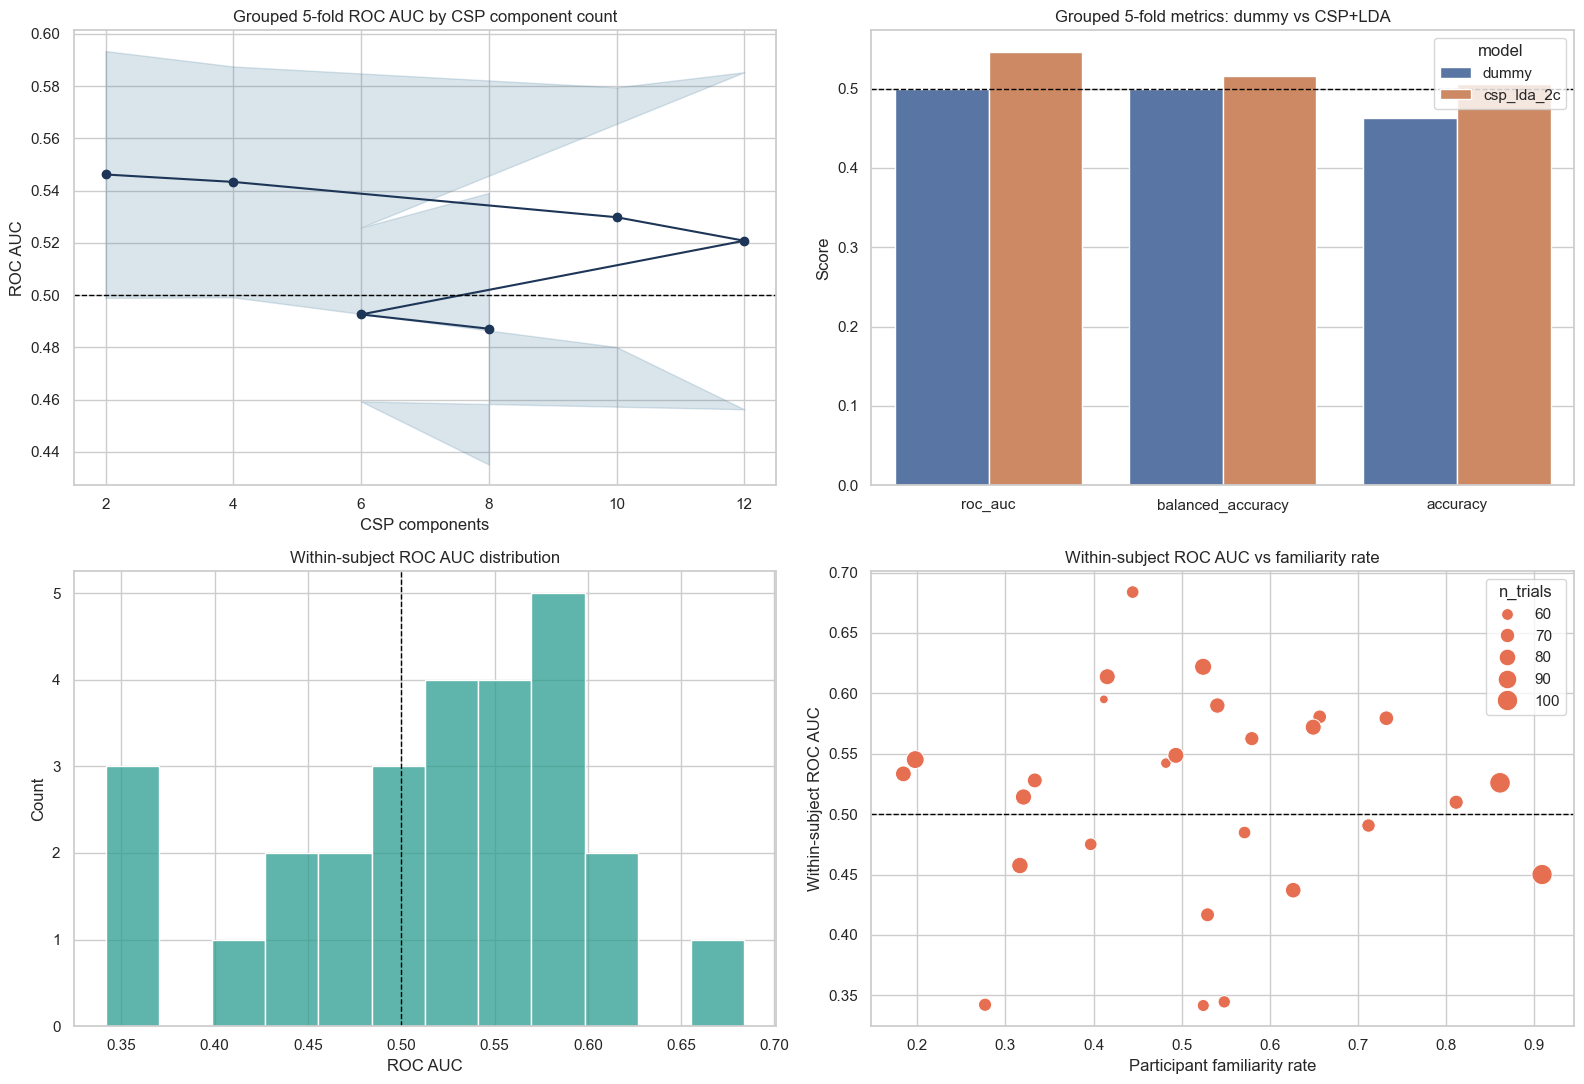

Saved tuning table to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\analysis\csp_lda_component_tuning.csv
Saved grouped results to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\analysis\csp_lda_grouped_results.csv
Saved LOSO subject results to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\analysis\csp_lda_loso_subject_results.csv
Saved within-subject results to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\analysis\csp_lda_within_subject_results.csv
Saved LOSO predictions to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\analysis\csp_lda_loso_predictions.csv
Saved summary plot to C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\visuals\analysis_ready\csp_lda_familiarity_summary.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top-left: how grouped ROC AUC changes as the CSP representation gets larger.
axes[0, 0].plot(tuning_df["n_components"], tuning_df["roc_auc_mean"], marker="o", color="#1d3557")
axes[0, 0].fill_between(
    tuning_df["n_components"],
    tuning_df["roc_auc_mean"] - tuning_df["roc_auc_std"],
    tuning_df["roc_auc_mean"] + tuning_df["roc_auc_std"],
    alpha=0.2,
    color="#457b9d",
)
axes[0, 0].axhline(0.5, linestyle="--", linewidth=1, color="black")
axes[0, 0].set_title("Grouped 5-fold ROC AUC by CSP component count")
axes[0, 0].set_xlabel("CSP components")
axes[0, 0].set_ylabel("ROC AUC")

# Top-right: direct dummy-vs-model comparison on the grouped metrics that matter most.
grouped_plot_df = grouped_df[["model", "roc_auc_mean", "balanced_accuracy_mean", "accuracy_mean"]].melt(
    id_vars="model",
    var_name="metric",
    value_name="score",
)
grouped_plot_df["metric"] = grouped_plot_df["metric"].str.replace("_mean", "", regex=False)
sns.barplot(data=grouped_plot_df, x="metric", y="score", hue="model", ax=axes[0, 1])
axes[0, 1].axhline(0.5, linestyle="--", linewidth=1, color="black")
axes[0, 1].set_title("Grouped 5-fold metrics: dummy vs CSP+LDA")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Score")

# Bottom-left: within-subject performance spread, which can be higher than the cross-subject result.
sns.histplot(valid_within_df["roc_auc_mean"], bins=12, color="#2a9d8f", edgecolor="white", ax=axes[1, 0])
axes[1, 0].axvline(0.5, linestyle="--", linewidth=1, color="black")
axes[1, 0].set_title("Within-subject ROC AUC distribution")
axes[1, 0].set_xlabel("ROC AUC")

# Bottom-right: check whether class balance and trial count partly explain who is easier to model.
sns.scatterplot(
    data=valid_within_df,
    x="familiar_rate",
    y="roc_auc_mean",
    size="n_trials",
    sizes=(40, 220),
    color="#e76f51",
    ax=axes[1, 1],
)
axes[1, 1].axhline(0.5, linestyle="--", linewidth=1, color="black")
axes[1, 1].set_title("Within-subject ROC AUC vs familiarity rate")
axes[1, 1].set_xlabel("Participant familiarity rate")
axes[1, 1].set_ylabel("Within-subject ROC AUC")

plt.tight_layout()
plt.savefig(SUMMARY_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved tuning table to {TUNING_PATH}")
print(f"Saved grouped results to {GROUPED_PATH}")
print(f"Saved LOSO subject results to {LOSO_PATH}")
print(f"Saved within-subject results to {WITHIN_PATH}")
print(f"Saved LOSO predictions to {PREDICTIONS_PATH}")
print(f"Saved summary plot to {SUMMARY_PLOT_PATH}")


## Result Notes

The grouped sweep peaks at 2 CSP components with `ROC AUC = 0.546 +/- 0.047`, which is a modest improvement over the dummy baseline (`0.500`). That suggests there may be some low-dimensional familiarity structure in the epoched EEG, but it is weak.

The stricter leave-one-subject-out result is the real check on generalization, and it largely collapses that lift: the overall out-of-fold ROC AUC is `0.504`, while the mean subject-level ROC AUC is about `0.493`. Within-subject ROC AUC averages around `0.514` with wide spread, which implies some individuals have idiosyncratic separability but there is no stable cross-subject decoder here. In practice, this notebook supports the claim that familiarity is only weakly modellable with a basic CSP + LDA pipeline on this dataset.

The interpretation should therefore be hierarchical:

1. There is enough structure for a very small grouped-validation lift above dummy at the best CSP dimensionality.
2. That lift does not survive the stricter unseen-participant test in any convincing way.
3. Some participant-specific signal may exist, but it is not a substitute for cross-subject generalization.

That combination is exactly why the notebook separates grouped tuning, LOSO evaluation, and within-subject reference checks instead of collapsing them into one headline score.


## Takeaway

If CSP + LDA is a good match for the data, it should rise above a dummy baseline under participant-aware validation. In this dataset, the grouped 5-fold result can show a small lift above chance for the best component count, but the stricter leave-one-subject-out evaluation is the more conservative answer to the original question. If that leave-one-subject-out score stays near 0.50, the data are only weakly modellable for familiarity using this pipeline.

More broadly, this notebook documents a useful modeling pattern for EEG classification:

- align labels carefully to epochs,
- tune hyperparameters with grouped validation,
- compare against a dummy baseline,
- separate cross-subject claims from within-subject diagnostics,
- and save predictions so errors remain inspectable after the run.

That workflow matters as much as the final score because it prevents overclaiming from optimistic validation schemes.
